# Backprop with a neuron function

## with a mathematical model of a nueron we are trying to learn back propagration

In [74]:
import math
import numpy as np
import matplotlib.pyplot as plt

#this line of code will show the graphs inside of the notebook, its jp notebook specific:-
%matplotlib inline 

## Value class
- the reason we are implementing this class is basically to keep a track of what operations led us to the result 
- simply said , we are traking the previoud nodes of the tree , and the tree itself is the arithmatic equation 
- we are also storing the gradient of the loss function, with respect to each node 
- the main benifit of using this data structre is that we can back propogate through the computation graph, to find out how each node influences the loss function 

In [75]:
class Value:
    
    def __init__(self, data, _children=(), _op='' , label=''):
         self.data = data
         self.prev = set(_children)
         self.op = _op
         self.label = label
         self.grad = 0  
         self._backward = lambda: None
    def __repr__(self):
         return f"Value(data={self.data})"
    
    def __add__(self, other):    
          out = Value(self.data + other.data, (self,other), '+')
          
          def _backward():
               self.grad = 1 * out.grad 
               other.grad = 1 * out.grad   
          out._backward = _backward     
               
          return out 

    def __mul__(self, other):
          out = Value(self.data * other.data, (self,other), '*') 
          
          def _backward():
               self.grad = other.data * out.grad
               other.grad = self.data * out.grad
          out._backward = _backward
               
          return out

    def tanh(self):
         x=self.data
         t=(math.exp(2*x) -1)/(math.exp(2*x)+1)
         output = Value(t, (self, ), 'tanh')
         
         def _backward():     
          self.grad =  (1-t**2)*output.grad
         output._backward = _backward
           
         return output

In [76]:
from graphviz import Digraph

def trace(root):
    """Build a set of all nodes and edges in the graph."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # value node (rounded box)
        dot.node(uid, label=f"{{ {n.label} | data: {n.data:.4f} | grad: {n.grad:.4f} }}", shape='record')
        # if this value was produced by an op, create an op node
        if n.op:
            op_uid = uid + n.op
            dot.node(op_uid, label=n.op)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        # connect n1 to n2's op node
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

In [83]:

# inputs are x and y
x=Value(2.0, label = 'x')
y=Value(0.0, label='y')

#weights w1, w2
w1=Value(-3.0, label = 'w1')
w2=Value(1.0, label = 'w2')

#bias of the neuron
b = Value(8, label = 'b')

#the neuron funtion:-
xw1=x*w1 ; xw1.label='x.w1'
yw2=y*w2 ; yw2.label='y.w2'

sum = xw1 + yw2 ; sum.label = 'sum'

neuron = sum + b; neuron.label ='neuron'

output = neuron.tanh() ; output.label = 'output'

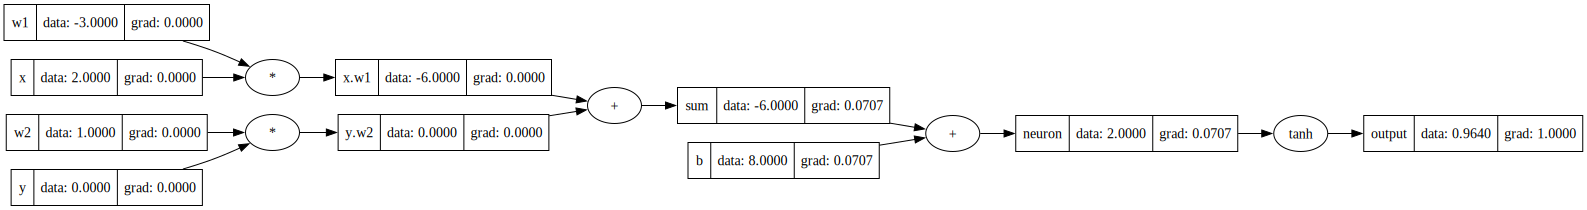

In [93]:
draw_dot(output)

## Here we would take a manual approach to fill up the gradients:-
- The last node here is the loss function and we would like to find the derivative of that function with respect to all its childdren 
- Basically we are trying to minimise the Loss function by back propagating through all the children nodes and computing the gradient to try adjust the weights, which would result in a minised Loss function
- the dereivative of the last with respect to itself is 1.0
- the derivative of the output function with respect to neuron node(tanh(neuron)) = d_output/d_neuron = 1-(tanh(neuron))^2 = (1-output^2)
- now we use the chain rule to find the derivatives all the other nodes:-
    - starting with d_output/d_summation = d_output/d_neuron * d_neuron/d_summation = neuron.grad * 1(the the serivative of sum+b with respect to sum is 1)
    - d_output/d_b = d_output/d_neuron * d_neuron/d_b = neuron.grad * 1(the the serivative of sum+b with respect to b is 1) 
    - d_output/(d_x.w1) = d_output/d_sum * d_sum/d_x.w1 = sum.grad * 1
    - d_output/(d_y.w2) = d_output/d_sum * d_sum/d_y.w2 = sum.grad * 1
    - d_output/d_w1 = d_output/d_x.w1 * d_x.w1/d_w1 = xw1.grad * x
    - d_output/d_x  = d_output/d_x.w1 * d_x.w1/d_x = xw1.grad * w1
    - d_output/d_w2 = d_output/d_y.w2 * d_y.w2/d_w2 = yw2.grad * y
    - d_output/d_y = d_output/d_y.w2 * d_y.w2/d_y = yw2.grad * w2

In [79]:
output.grad = 1.0
neuron.grad = 1 - (output.data**2)
sum.grad = neuron.grad * 1
b.grad = neuron.grad * 1
xw1.grad = sum.grad * 1
yw2.grad = sum.grad * 1
w1.grad = xw1.grad * x.data
x.grad = xw1.grad * w1.data
w2.grad = yw2.grad * y.data
y.grad = yw2.grad * w2.data

In [87]:
output.grad = 1
output._backward()


In [ ]:
sum._backward()